![](https://blog.kakaocdn.net/dn/9BSX3/btqVIazRtst/PAddeQABCVTV6bLwUtamg0/img.jpg)

#  Titanic disaster

## Table of Contents.
<a id="table-of-contents"></a>
- [0 Load Library and Data](#0)
- [1 Check the Data structure](#1)
- [2 EDA with Tableau ](#2)
- [3 Data Preprocessing](#3)
   - [3.1 NA Impute with mice](#3.1)
   - [3.2 Feature Gneration](#3.2)
- [4 Modeling](#4)
    - [4.1 7 models with Validation](#5.1)
    - [4.2 Compare](#5.2)
    - [4.3 Prediction](#5.3)
    
https://www.kaggle.com/imakash3011/water-quality-prediction-7-model

**Hello Kaggle users and friends😀,** starting today, I'm going to get away from R programs for a while and try Python. To be honest, there seems to be a lot of difference between R and R. 
**Please rate my lack of coding skills and share your thoughts.**

[back to top](#table-of-contents)
<a id="0"></a>
# 0 Load Library and Data

In [1]:
pip install impyute

Note: you may need to restart the kernel to use updated packages.


In [2]:
#library
import sklearn
import numpy as np
import pandas as pd #read.csv
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from impyute.imputation.cs import mice
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import AdaBoostClassifier

In [3]:
#data
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')
sample_submission = pd.read_csv('../input/titanic/gender_submission.csv')

[back to top](#table-of-contents)
<a id="1"></a>
# 1 Check the Data structure

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


[back to top](#table-of-contents)
<a id="2"></a>
# 2 EDA with Tableau

**The main purpose of EDA** is to help look at data before making any assumptions. It can help identify obvious errors, as well as better understand patterns within the data, detect outliers or anomalous events, find interesting relations among the variables.

So, My purpose of EDA is to find out **'Who will survive the best?'**. So, I will look at the distribution of each variable around a variable called Survive.

In [6]:
train_eda = train.drop(['Name','Ticket','Cabin'],axis=1)

## 2.1 What is Tableau?

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2021/03/Tableau-Logo-for-website.jpg)

Tableau is a Business Intelligence tool for visually analyzing the data. Users can create and distribute an interactive and shareable dashboard, which depict the trends, variations, and density of the data in the form of graphs and charts. Tableau can connect to files, relational and Big Data sources to acquire and process data. The software allows data blending and real-time collaboration, which makes it very unique. It is used by businesses, academic researchers, and many government organizations for visual data analysis.
​
**Furthermore, It has more visualization power than R and Python, So If you learned this tools, you can easily show your insight and perspective.**

## 2.2 EDA

### 2.2.1 Pclass by Survived

<div class='tableauPlaceholder' id='viz1630909442221' style='position: relative'><noscript><a href='#'><img alt='대시보드 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;pc&#47;pclass2&#47;1_1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='pclass2&#47;1_1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;pc&#47;pclass2&#47;1_1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='ko-KR' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1630909442221');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='800px';vizElement.style.height='627px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

Pclass of 3 is less likely to survive, 1 is more likely to survive. **Perhaps the wealthiest** who can afford first-class have a higher chance of surviving because they are at the top of the hull.

### 2.2.2 Sex by Survived

<div class='tableauPlaceholder' id='viz1630910246895' style='position: relative'><noscript><a href='#'><img alt='대시보드 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;se&#47;sex_16309100700500&#47;1_1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='sex_16309100700500&#47;1_1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;se&#47;sex_16309100700500&#47;1_1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='ko-KR' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1630910246895');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='800px';vizElement.style.height='627px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**Men were much less likely to live than women, suggesting that men are probably less likely to survive to help in rescue.**

### 2.2.3 Age by Survived

<div class='tableauPlaceholder' id='viz1630913064904' style='position: relative'><noscript><a href='#'><img alt='대시보드 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;ag&#47;age_16309128769590&#47;1_1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='age_16309128769590&#47;1_1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;ag&#47;age_16309128769590&#47;1_1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='ko-KR' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1630913064904');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='800px';vizElement.style.height='627px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**Obviously, the younger you are, the more likely you are to survive, which means you saved the children first.**

### 2.2.4 Sibsip, Parch by Survived

<div class='tableauPlaceholder' id='viz1630913812950' style='position: relative'><noscript><a href='#'><img alt='대시보드 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;si&#47;sibparch&#47;1_1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='sibparch&#47;1_1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;si&#47;sibparch&#47;1_1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='ko-KR' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1630913812950');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='800px';vizElement.style.height='627px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>



### 2.2.5 Fare by Survived

<div class='tableauPlaceholder' id='viz1630914273621' style='position: relative'><noscript><a href='#'><img alt='대시보드 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;fa&#47;fare_16309140391250&#47;1_1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='fare_16309140391250&#47;1_1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;fa&#47;fare_16309140391250&#47;1_1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='ko-KR' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1630914273621');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='800px';vizElement.style.height='627px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>


**The richer they were, the fewer those on board, and the higher the fares they would have paid. So, looking at this chart, it can be clearly seen that the richer the person, the higher the probability of survival.**

### 2.2.6 Embarkement by Survived

<div class='tableauPlaceholder' id='viz1630915092511' style='position: relative'><noscript><a href='#'><img alt='대시보드 1 ' src='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;em&#47;embarkement&#47;1_1&#47;1_rss.png' style='border: none' /></a></noscript><object class='tableauViz'  style='display:none;'><param name='host_url' value='https%3A%2F%2Fpublic.tableau.com%2F' /> <param name='embed_code_version' value='3' /> <param name='site_root' value='' /><param name='name' value='embarkement&#47;1_1' /><param name='tabs' value='no' /><param name='toolbar' value='yes' /><param name='static_image' value='https:&#47;&#47;public.tableau.com&#47;static&#47;images&#47;em&#47;embarkement&#47;1_1&#47;1.png' /> <param name='animate_transition' value='yes' /><param name='display_static_image' value='yes' /><param name='display_spinner' value='yes' /><param name='display_overlay' value='yes' /><param name='display_count' value='yes' /><param name='language' value='ko-KR' /><param name='filter' value='publish=yes' /></object></div>                <script type='text/javascript'>                    var divElement = document.getElementById('viz1630915092511');                    var vizElement = divElement.getElementsByTagName('object')[0];                    vizElement.style.width='800px';vizElement.style.height='627px';                    var scriptElement = document.createElement('script');                    scriptElement.src = 'https://public.tableau.com/javascripts/api/viz_v1.js';                    vizElement.parentNode.insertBefore(scriptElement, vizElement);                </script>

**As you can see from this chart, the S rides the most, and there are a lot of people who aren't rich. It is possible to guess that C and other places are rich neighborhoods, and their survival rate is high.**

## 2.3 Correlation and Result

<AxesSubplot:>

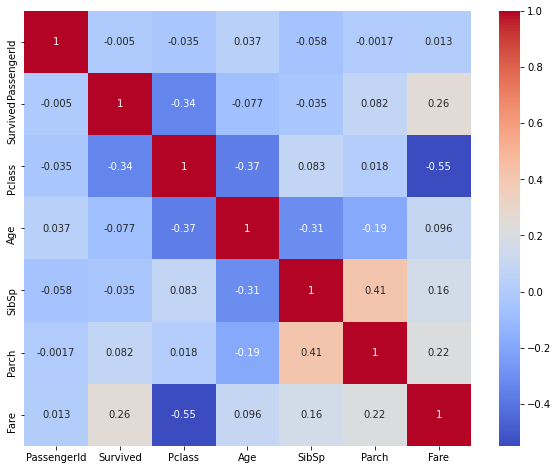

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_eda.corr(), annot= True, cmap='coolwarm')

So we can view in this numeric version that most survived persons equals who have upper **Pclass, Female, Parch, More Fare,Not embarked in Southampton**. So I decided to generate feature called **'Mother'**, **'rich'**

[back to top](#table-of-contents)
<a id="3"></a>
# 3 Data Preprocessing

## 3.1 NA Impute with mode data

In [8]:
print(train_eda.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64


In [9]:
imp_mode = SimpleImputer( strategy='most_frequent') #'median'을 쓰면 중앙값사용
imp_mode.fit(train_eda)
train_imputed = pd.DataFrame(imp_mode.transform(train_eda))
train_imputed.columns = ['PassengerId', 'Survived', 'Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']

## 3.2 Feature generation

In [10]:
train_imputed

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.25,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.925,S
3,4,1,1,female,35.0,1,0,53.1,S
4,5,0,3,male,35.0,0,0,8.05,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0,S
887,888,1,1,female,19.0,0,0,30.0,S
888,889,0,3,female,24.0,1,2,23.45,S
889,890,1,1,male,26.0,0,0,30.0,C


In [11]:
#Create cols
mother = train_imputed[(train_imputed['Sex']=='female') & (train_imputed['Parch']>0)]
rich = train_imputed[(train_imputed['Fare']> 46.4) & ~(train_imputed['Embarked']=='S')]

#add value
mother['mother'] = 1
mother = mother[['PassengerId','mother']]

rich['rich'] = 1
rich = rich[['PassengerId','rich']]

#merge with PassengerId
train_merge= pd.merge(train_imputed, mother, how='left', on='PassengerId')
train_merge= pd.merge(train_merge, rich, how='left', on='PassengerId')

#train_merge
train_fin = train_merge.fillna(0)

#Sex to numeric
train_fin.loc[train_fin.Sex=='female','Sex']=1
train_fin.loc[train_fin.Sex=='male','Sex']=0
train_fin["Sex"] = train_fin["Sex"].astype(str).astype(float)

#Embarked to numeric
train_fin.loc[train_fin.Embarked =='S','Embarked']= 3
train_fin.loc[train_fin.Embarked =='C','Embarked']=2
train_fin.loc[train_fin.Embarked =='Q','Embarked']=1
train_fin["Embarked"] = train_fin["Embarked"].astype(str).astype(float)

#Erase trainest PassengerID
train_fin = train_fin.drop(['PassengerId'],axis=1)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if __name__ == '__main__':


[back to top](#table-of-contents)
<a id="4"></a>
# 4 Modeling

## 4.1 7 models with Validation

In [12]:
#set x,y
x = train_fin.drop('Survived', axis=1)
y = train_fin['Survived']

#scale
scaler = StandardScaler()
x = scaler.fit_transform(x)

#split train and validation
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.5, shuffle=True, stratify=y, random_state=34)

In [13]:
#1. Logistic regression
model_lg = LogisticRegression(max_iter=120,random_state=0, n_jobs=20)

#2. Decision Tree Classifier
model_dt = DecisionTreeClassifier( max_depth=4, random_state=42)

#3. Random Forest
model_rf = RandomForestClassifier(n_estimators=300,min_samples_leaf=0.16, random_state=42)

#4. XGB
model_xgb = XGBClassifier(max_depth= 8, n_estimators= 125, random_state= 0,  learning_rate= 0.03, n_jobs=5)

#5.KNN
model_kn = KNeighborsClassifier(n_neighbors=9, leaf_size=20)

#6.SVM
model_svm = SVC(kernel='rbf', random_state = 42)

#7. AdaBoost
model_ada = AdaBoostClassifier(learning_rate= 0.002,n_estimators= 205,random_state=42)

# Training Model
model_lg.fit(x_train, y_train)
model_dt.fit(x_train,y_train)
model_rf.fit(x_train, y_train)
model_xgb.fit(x_train, y_train)
model_kn.fit(x_train, y_train)
model_svm.fit(x_train, y_train)
model_ada.fit(x_train, y_train)

/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:1146: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[21:38:37] WARNING: ../src/learner.cc:1095: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


AdaBoostClassifier(learning_rate=0.002, n_estimators=205, random_state=42)

### 4.1.1 Prediction

In [14]:
# Making Prediction
pred_lg = model_lg.predict(x_valid)
pred_dt = model_dt.predict(x_valid)
pred_rf = model_rf.predict(x_valid)
pred_xgb = model_xgb.predict(x_valid)
pred_kn = model_kn.predict(x_valid)
pred_svm = model_svm.predict(x_valid)
pred_ada = model_ada.predict(x_valid)

## 4.2 Compare

In [15]:
#accurarcy score
lg = accuracy_score(y_valid, pred_lg)
dt = accuracy_score(y_valid, pred_dt)
rf = accuracy_score(y_valid, pred_rf)
xgb = accuracy_score(y_valid, pred_xgb)
kn = accuracy_score(y_valid, pred_kn)
sv = accuracy_score(y_valid, pred_svm)
ada = accuracy_score(y_valid, pred_ada)


print(lg)
print(dt)
print(rf)
print(xgb)
print(kn)
print(sv)
print(ada)

0.7937219730941704
0.7982062780269058
0.773542600896861
0.8094170403587444
0.8139013452914798
0.8139013452914798
0.7802690582959642


### 4.2.1 Graph

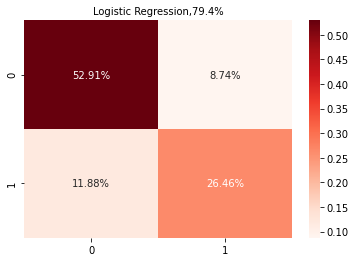

In [16]:
# Logistic
cm1 = confusion_matrix(y_valid, pred_lg)
sns.heatmap(cm1/np.sum(cm1), annot = True, fmt=  '0.2%', cmap = 'Reds')
plt.title('Logistic Regression,79.4%', fontsize = 10)
plt.show()

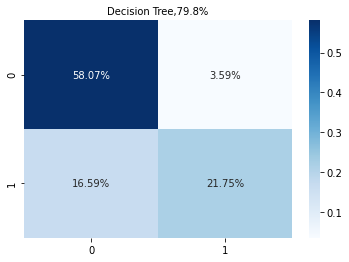

In [17]:
# Decision Tree
cm2 = confusion_matrix(y_valid, pred_dt)
sns.heatmap(cm2/np.sum(cm2), annot = True, fmt=  '0.2%', cmap = 'Blues')
plt.title('Decision Tree,79.8%', fontsize = 10)
plt.show()

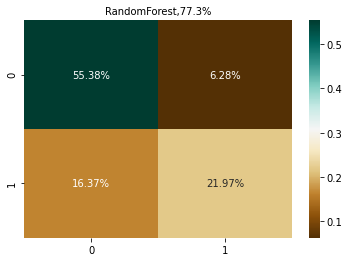

In [18]:
# RandomForest
cm3 = confusion_matrix(y_valid, pred_rf)
sns.heatmap(cm3/np.sum(cm3), annot = True, fmt=  '0.2%', cmap = 'BrBG')
plt.title('RandomForest,77.3%', fontsize = 10)
plt.show()

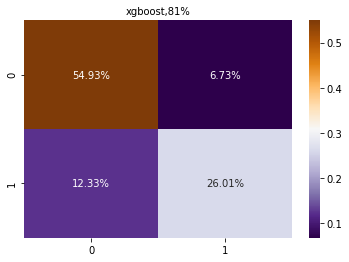

In [19]:
# XGboost
cm4 = confusion_matrix(y_valid, pred_xgb)
sns.heatmap(cm4/np.sum(cm4), annot = True, fmt=  '0.2%', cmap = 'PuOr_r')
plt.title('xgboost,81%', fontsize = 10)
plt.show()

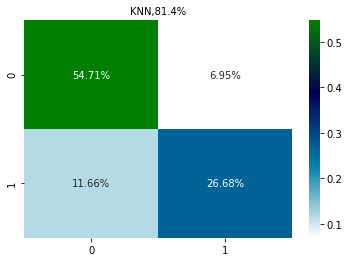

In [20]:
# KNN 
cm5 = confusion_matrix(y_valid, pred_kn)
sns.heatmap(cm5/np.sum(cm5), annot = True, fmt=  '0.2%', cmap = 'ocean_r')
plt.title('KNN,81.4%', fontsize = 10)
plt.show()

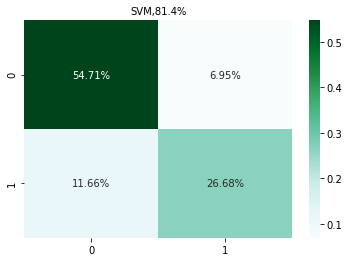

In [21]:
# SVM
cm6 = confusion_matrix(y_valid, pred_kn)
sns.heatmap(cm6/np.sum(cm6), annot = True, fmt=  '0.2%', cmap = 'BuGn')
plt.title('SVM,81.4%', fontsize = 10)
plt.show()

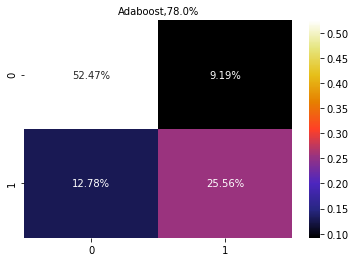

In [22]:
# Adaboost
cm7 = confusion_matrix(y_valid, pred_ada)
sns.heatmap(cm7/np.sum(cm7), annot = True, fmt=  '0.2%', cmap = 'CMRmap')
plt.title('Adaboost,78.0%', fontsize = 10)
plt.show()

,Model,Accuracy_score
4,KNeighbours,0.813901
5,SVM,0.813901
3,XGBoost,0.809417
1,Decision Tree,0.798206
0,Logistic Regression,0.793722
6,AdaBoost,0.780269
2,Random Forest,0.773543


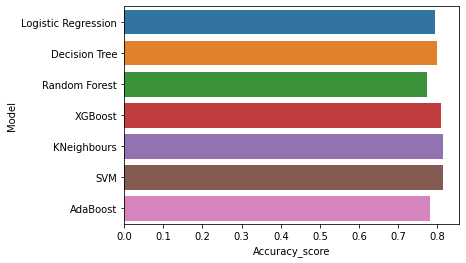

In [23]:
models = pd.DataFrame({
    'Model':['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'KNeighbours', 'SVM', 'AdaBoost'],
    'Accuracy_score' :[lg, dt, rf, xgb, kn, sv, ada]
})
models
sns.barplot(x='Accuracy_score', y='Model', data=models)

models.sort_values(by='Accuracy_score', ascending=False)


**The most recorded model is 'KNN' and 'SVM'**

## 4.3 Prediction

### 4.3.1 Reday for testset

In [24]:
#Ready for testset
test_eda = test.drop(['Name','Ticket','Cabin'],axis=1)
imp_mode = SimpleImputer( strategy='most_frequent') #'median'을 쓰면 중앙값사용
imp_mode.fit(test_eda)
test_imputed = pd.DataFrame(imp_mode.transform(test_eda))
test_imputed.columns = ['PassengerId', 'Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']

#Create cols
mother = test_imputed[(test_imputed['Sex']=='female') & (test_imputed['Parch']>0)]
rich = test_imputed[(test_imputed['Fare']> 46.4) & ~(test_imputed['Embarked']=='S')]

#add value
mother['mother'] = 1
mother = mother[['PassengerId','mother']]

rich['rich'] = 1
rich = rich[['PassengerId','rich']]

#merge with PassengerId
test_merge= pd.merge(test_imputed, mother, how='left', on='PassengerId')
test_merge= pd.merge(test_merge, rich, how='left', on='PassengerId')

#test_merge
test_fin = test_merge.fillna(0)

#Sex to numeric
test_fin.loc[test_fin.Sex=='female','Sex']=1
test_fin.loc[test_fin.Sex=='male','Sex']=0
test_fin["Sex"] = test_fin["Sex"].astype(str).astype(float)

#Embarked to numeric
test_fin.loc[test_fin.Embarked =='S','Embarked']= 3
test_fin.loc[test_fin.Embarked =='C','Embarked']=2
test_fin.loc[test_fin.Embarked =='Q','Embarked']=1
test_fin["Embarked"] = test_fin["Embarked"].astype(str).astype(float)

#Erase testest PassengerID
test_fin = test_fin.drop(['PassengerId'],axis=1)

x_test = scaler.fit_transform(test_fin)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  app.launch_new_instance()


### 4.3.2 Prediction

In [25]:
#KNN
model_kn = KNeighborsClassifier(n_neighbors=9, leaf_size=20)
model_kn.fit(x, y)
pred_kn = model_kn.predict(x_test)
pred_kn = pd.DataFrame(pred_kn)

In [26]:
#submission
sub = sample_submission.drop(['Survived'],axis=1)
sub['Survived'] = pred_kn
sub.to_csv('submission.csv', index = False)

First of all, compared to R, **there are different parts and there are similar parts,** so it was not difficult to adapt. However, as with most computer languages, it will take some time to get used to as the meaning changes at one point.